# ControlGen Mechanistic Visualization

This notebook visualizes the modular control-graph samples generated by ControlGen, including a control-system structure diagram and the full signal chain.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from notebook path")


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/controlgen-mpl")

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

from controlgen.generator import DatasetConfig, generate_sample

plt.style.use("seaborn-v0_8-whitegrid")
ROOT


PosixPath('/home/fan/AP/ControlGen')

In [2]:
ROLE_COLORS = {
    "reference": "#7c3aed",
    "sum": "#475569",
    "controller": "#0f766e",
    "actuator": "#0ea5e9",
    "plant": "#f97316",
    "sensor": "#16a34a",
    "disturbance": "#dc2626",
    "noise": "#e11d48",
}


def load_jsonl_sample(path: Path, index: int = 0) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        for line_no, line in enumerate(handle):
            if line_no == index:
                return json.loads(line)
    raise IndexError(f"Sample index {index} out of range for {path}")


def summarize_sample(sample: dict) -> None:
    print("sample_id:", sample["sample_id"])
    print("graph_dsl:", sample["graph_dsl"])
    print("tags:", sample["tags"])
    print("scenario:", sample["scenario"])
    print("module_params:")
    for name, params in sample["module_params"].items():
        print(f"  {name}: {params}")
    print("metrics:")
    for family, values in sample["metrics"].items():
        print(f"  {family}: {values}")


def extract_graph_view(sample: dict) -> dict:
    graph = sample.get("graph_ast", {}) or {}
    return {
        "reference": graph.get("reference"),
        "sum": graph.get("sum"),
        "controller": graph.get("controller"),
        "actuator": graph.get("actuator"),
        "plant": graph.get("plant"),
        "sensor": graph.get("sensor"),
        "disturbance": graph.get("disturbance"),
        "noise": graph.get("noise"),
        "taps": graph.get("taps", []),
    }


def _clean_kind(node: dict | None, default: str = "none") -> str:
    if not node:
        return default
    return str(node.get("kind", default)).replace("_", " ")


def _format_param_value(value: object) -> str:
    if isinstance(value, float):
        return f"{value:.2f}"
    return str(value)


def _parameter_summary(role: str, params: dict | None) -> str:
    if not params:
        return ""

    preferred_keys = {
        "controller": ["kp", "ki", "kd", "tau"],
        "actuator": ["gain", "tau", "saturation_limit"],
        "plant": ["gain", "tau", "zeta", "delay"],
        "sensor": ["gain", "tau", "bias"],
        "disturbance": ["gain", "tau", "injection"],
        "noise": ["std", "tau", "bandwidth"],
    }

    parts = []
    for key in preferred_keys.get(role, []):
        if key in params and params[key] is not None:
            label = "sat" if key == "saturation_limit" else key
            parts.append(f"{label}={_format_param_value(params[key])}")
        if len(parts) == 3:
            break
    return "\n".join(parts)


def format_module_label(role: str, graph_node: dict | None, params: dict | None) -> str:
    role_title = role.replace("_", " ").title()
    kind = _clean_kind(graph_node)
    summary = _parameter_summary(role, params)
    label = f"{role_title}\n{kind}"
    if summary:
        label = f"{label}\n{summary}"
    return label


def _draw_block(ax, center: tuple[float, float], width: float, height: float, label: str, color: str, ideal: bool = False) -> None:
    x = center[0] - width / 2
    y = center[1] - height / 2
    rect = Rectangle(
        (x, y),
        width,
        height,
        facecolor="white",
        edgecolor=color,
        linewidth=2.0 if not ideal else 1.5,
        linestyle="--" if ideal else "-",
        zorder=2,
    )
    ax.add_patch(rect)
    ax.text(center[0], center[1], label, ha="center", va="center", fontsize=10, color="#111827", zorder=3)


def _draw_arrow(ax, start: tuple[float, float], end: tuple[float, float], text: str | None = None, color: str = "#334155", text_offset: tuple[float, float] = (0.0, 0.0)) -> None:
    arrow = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=12, linewidth=1.8, color=color, shrinkA=0, shrinkB=0, zorder=1)
    ax.add_patch(arrow)
    if text:
        mid_x = (start[0] + end[0]) / 2 + text_offset[0]
        mid_y = (start[1] + end[1]) / 2 + text_offset[1]
        ax.text(mid_x, mid_y, text, fontsize=10, color=color, ha="center", va="center", zorder=4)


def plot_control_structure(sample: dict, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 4.5))

    graph = extract_graph_view(sample)
    params = sample.get("module_params", {})

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    ref_pos = (0.08, 0.62)
    sum_pos = (0.22, 0.62)
    ctrl_pos = (0.38, 0.62)
    act_pos = (0.56, 0.62)
    plant_pos = (0.76, 0.62)
    output_pos = (0.93, 0.62)
    sensor_pos = (0.56, 0.22)
    disturbance_pos = (0.76, 0.90)
    noise_pos = (0.56, 0.90)

    _draw_block(
        ax,
        ref_pos,
        0.11,
        0.14,
        format_module_label("reference", graph["reference"], sample.get("scenario", {}).get("reference")),
        ROLE_COLORS["reference"],
    )

    sum_circle = Circle(sum_pos, 0.035, facecolor="white", edgecolor=ROLE_COLORS["sum"], linewidth=2.0, zorder=2)
    ax.add_patch(sum_circle)
    ax.text(sum_pos[0], sum_pos[1], "Σ", ha="center", va="center", fontsize=14, color=ROLE_COLORS["sum"], zorder=3)
    ax.text(sum_pos[0] - 0.012, sum_pos[1] + 0.055, "+", fontsize=11, color=ROLE_COLORS["sum"], zorder=3)
    ax.text(sum_pos[0] - 0.014, sum_pos[1] - 0.072, "-", fontsize=13, color=ROLE_COLORS["sum"], zorder=3)

    _draw_block(
        ax,
        ctrl_pos,
        0.16,
        0.18,
        format_module_label("controller", graph["controller"], params.get("controller")),
        ROLE_COLORS["controller"],
    )

    actuator_node = graph.get("actuator")
    actuator_kind = actuator_node.get("kind", "ideal") if actuator_node else "ideal"
    _draw_block(
        ax,
        act_pos,
        0.16,
        0.18,
        format_module_label("actuator", actuator_node, params.get("actuator")),
        ROLE_COLORS["actuator"],
        ideal=actuator_kind == "ideal",
    )

    plant_node = graph.get("plant")
    _draw_block(
        ax,
        plant_pos,
        0.18,
        0.20,
        format_module_label("plant", plant_node, params.get("plant")),
        ROLE_COLORS["plant"],
    )

    sensor_node = graph.get("sensor")
    sensor_kind = sensor_node.get("kind", "ideal") if sensor_node else "ideal"
    _draw_block(
        ax,
        sensor_pos,
        0.18,
        0.16,
        format_module_label("sensor", sensor_node, params.get("sensor")),
        ROLE_COLORS["sensor"],
        ideal=sensor_kind == "ideal",
    )

    _draw_arrow(ax, (0.135, 0.62), (sum_pos[0] - 0.035, 0.62), text="r", color=ROLE_COLORS["reference"], text_offset=(0.0, 0.04))
    _draw_arrow(ax, (sum_pos[0] + 0.035, 0.62), (ctrl_pos[0] - 0.08, 0.62), text="e", text_offset=(0.0, 0.04))
    _draw_arrow(ax, (ctrl_pos[0] + 0.08, 0.62), (act_pos[0] - 0.08, 0.62), text="u_cmd", text_offset=(0.0, 0.04))
    _draw_arrow(ax, (act_pos[0] + 0.08, 0.62), (plant_pos[0] - 0.09, 0.62), text="u_act", text_offset=(0.0, 0.04))
    _draw_arrow(ax, (plant_pos[0] + 0.09, 0.62), output_pos, text="y", text_offset=(0.0, 0.04))
    ax.text(output_pos[0] + 0.015, output_pos[1], "Output", fontsize=10, color="#111827", va="center")

    ax.plot([output_pos[0], output_pos[0]], [0.62, 0.22], color=ROLE_COLORS["sensor"], linewidth=1.8, zorder=1)
    _draw_arrow(ax, (output_pos[0], 0.22), (sensor_pos[0] + 0.09, 0.22), color=ROLE_COLORS["sensor"], text="y", text_offset=(0.0, 0.04))
    _draw_arrow(ax, (sensor_pos[0] - 0.09, 0.22), (sum_pos[0], 0.22), color=ROLE_COLORS["sensor"], text="y_m", text_offset=(0.0, -0.05))
    ax.plot([sum_pos[0], sum_pos[0]], [0.22, sum_pos[1] - 0.035], color=ROLE_COLORS["sensor"], linewidth=1.8, zorder=1)

    disturbance_node = graph.get("disturbance")
    if disturbance_node is not None:
        _draw_block(
            ax,
            disturbance_pos,
            0.16,
            0.14,
            format_module_label("disturbance", disturbance_node, sample.get("scenario", {}).get("disturbance")),
            ROLE_COLORS["disturbance"],
        )
        _draw_arrow(ax, (disturbance_pos[0], disturbance_pos[1] - 0.07), (plant_pos[0], 0.72), text="d", color=ROLE_COLORS["disturbance"], text_offset=(-0.03, 0.0))

    noise_node = graph.get("noise")
    if noise_node is not None:
        _draw_block(
            ax,
            noise_pos,
            0.14,
            0.14,
            format_module_label("noise", noise_node, sample.get("scenario", {}).get("noise")),
            ROLE_COLORS["noise"],
        )
        _draw_arrow(ax, (noise_pos[0], noise_pos[1] - 0.07), (sensor_pos[0], 0.30), text="n", color=ROLE_COLORS["noise"], text_offset=(-0.03, 0.0))

    taps = graph.get("taps", [])
    if taps:
        tap_names = ", ".join(tap.get("signal", "?") for tap in taps)
        ax.text(0.02, 0.03, f"Observed taps: {tap_names}", fontsize=9, color="#475569", ha="left", va="bottom")

    ax.set_title("Control Structure Diagram", fontsize=13, pad=10)
    return ax


def plot_sample(sample: dict) -> None:
    t = np.asarray(sample["t"], dtype=float)
    signals = {name: np.asarray(values, dtype=float) for name, values in sample["signals"].items()}

    fig = plt.figure(figsize=(16, 10))
    grid = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.1])
    ax_structure = fig.add_subplot(grid[0, :])
    ax_external = fig.add_subplot(grid[1, 0])
    ax_control = fig.add_subplot(grid[1, 1], sharex=ax_external)
    ax_output = fig.add_subplot(grid[1, 2], sharex=ax_external)

    plot_control_structure(sample, ax=ax_structure)

    ax_external.plot(t, signals["r"], linewidth=2, label="r")
    ax_external.plot(t, signals["d"], linewidth=2, label="d")
    ax_external.plot(t, signals["n"], linewidth=1.5, label="n")
    ax_external.set_title("External Signals")
    ax_external.set_xlabel("Time [s]")
    ax_external.legend(loc="upper right")

    ax_control.plot(t, signals["e"], linewidth=2, label="e")
    ax_control.plot(t, signals["u_cmd"], linewidth=2, label="u_cmd")
    ax_control.plot(t, signals["u_act"], linewidth=2, label="u_act")
    ax_control.set_title("Control Chain")
    ax_control.set_xlabel("Time [s]")
    ax_control.legend(loc="upper right")

    ax_output.plot(t, signals["y"], linewidth=2, label="y")
    ax_output.plot(t, signals["y_m"], linewidth=2, label="y_m")
    ax_output.plot(t, signals["r"], linewidth=1.5, linestyle="--", label="r")
    ax_output.set_title("Plant / Measurement Output")
    ax_output.set_xlabel("Time [s]")
    ax_output.legend(loc="upper right")

    fig.suptitle(sample["sample_id"], fontsize=15)
    fig.tight_layout()
    plt.show()


## Generate a fresh sample

This cell draws a new mechanistic control-graph sample, shows its block-diagram structure, and visualizes the full signal chain.

sample_id: c21668f35152
graph_dsl: loop(reference=reference(kind='step', name='reference'), sum=sum(signs=[1, -1], name='error_sum'), controller=controller(kind='pid', name='controller'), actuator=actuator(kind='ideal', name='actuator'), plant=plant(kind='second_order', name='plant'), disturbance=disturbance(kind='filtered_noise', injection='output', name='disturbance'), sensor=sensor(kind='lag', name='sensor'), noise=None, taps=[tap(signal='r', name='tap_r'), tap(signal='d', name='tap_d'), tap(signal='e', name='tap_e'), tap(signal='u_cmd', name='tap_u_cmd'), tap(signal='u_act', name='tap_u_act'), tap(signal='y', name='tap_y'), tap(signal='y_m', name='tap_y_m')])
tags: {'structure_family': 'disturbance_rejection_loop', 'controller_family': 'pid', 'actuator_family': 'ideal', 'plant_family': 'second_order', 'sensor_family': 'lag', 'disturbance_family': 'filtered_noise', 'noise_family': 'none', 'reference_family': 'step', 'realism_level': 'linear_with_disturbance_and_limits', 'closed_loop

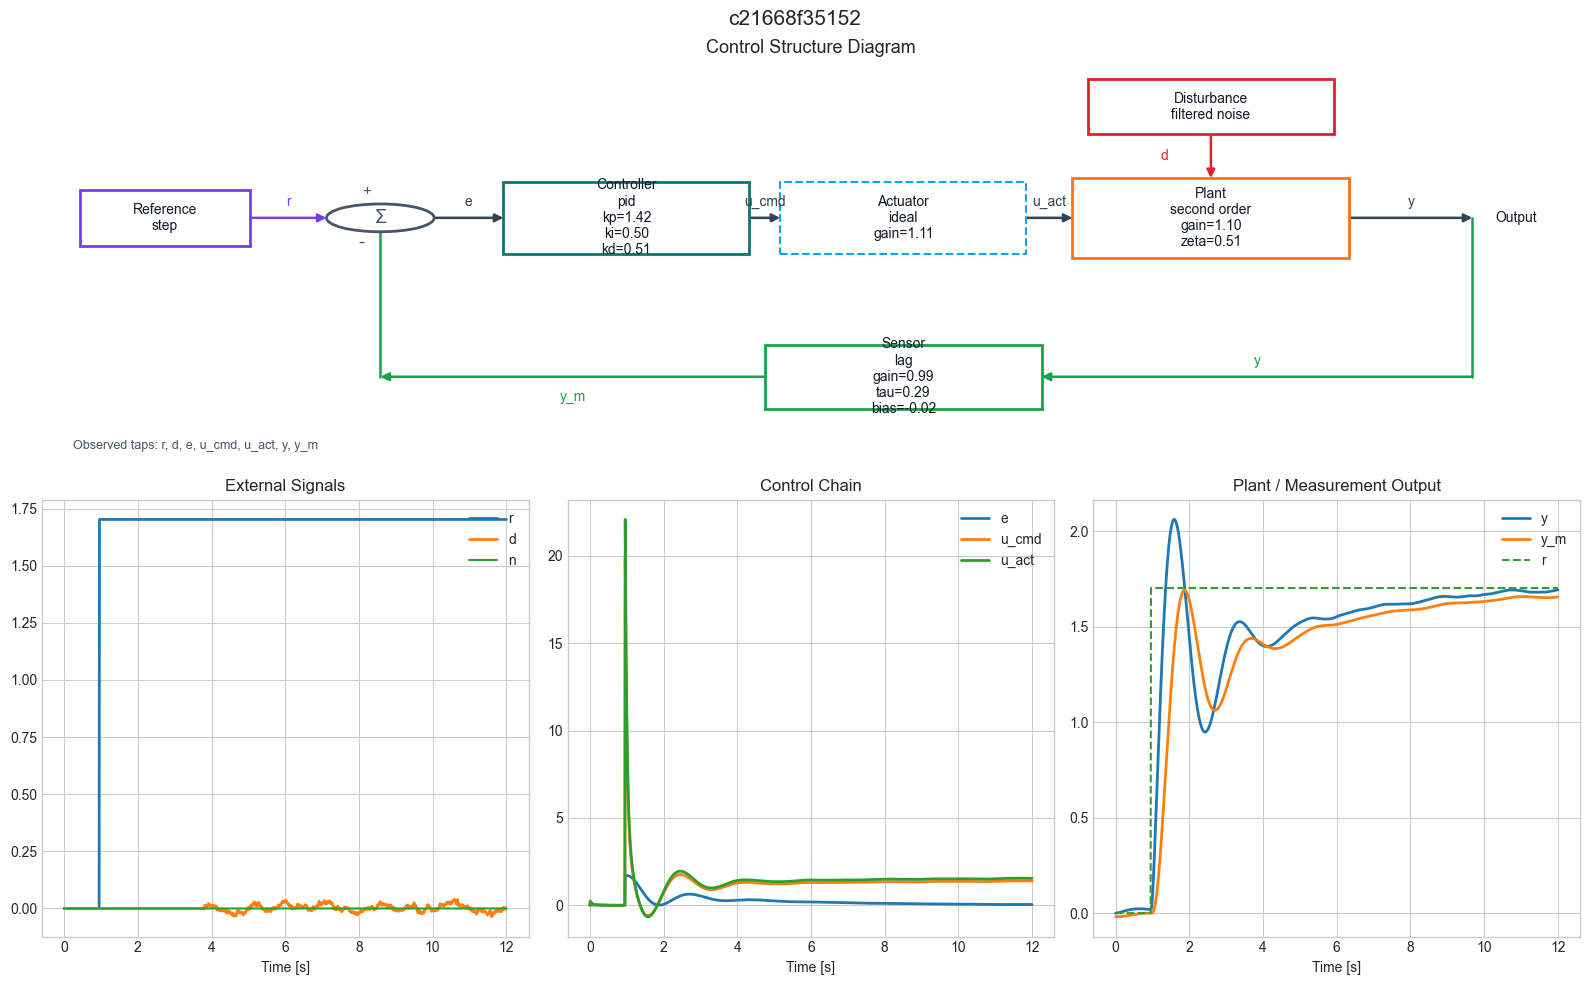

In [7]:
generated = generate_sample(DatasetConfig(seed=47, count=1), sample_index=0).to_dict()
summarize_sample(generated)
plot_sample(generated)

## Load a sample from exported JSONL

After exporting data with `python3 -m controlgen.cli --count 100 --output artifacts/samples.jsonl`,
set `JSONL_PATH` and `SAMPLE_INDEX` below to inspect a saved row.

In [4]:
JSONL_PATH = ROOT / "artifacts" / "samples.jsonl"
SAMPLE_INDEX = 0

if JSONL_PATH.exists():
    loaded = load_jsonl_sample(JSONL_PATH, index=SAMPLE_INDEX)
    summarize_sample(loaded)
    plot_sample(loaded)
else:
    print(f"No JSONL file found at {JSONL_PATH}")

No JSONL file found at /home/fan/AP/ControlGen/artifacts/samples.jsonl
